In [1]:
# colab setup
colab = False

In [26]:
%load_ext autoreload
%autoreload 2
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/ecg_arrhythmia/
    !pip install wfdb wget numpy pandas scipy scikit-learn tensorflow matplotlib seaborn PyWavelets
    !pip install --upgrade wfdb
    !pip install neurokit2
from hyperparams import *
from tasks import *
from plot import *
from model import *
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

gridsearch_path = './gridsearch_seed/'
if not os.path.exists(gridsearch_path):
    os.makedirs(gridsearch_path)
resfile_name = 'splitseed0-39_withgroup_classweight.csv' 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
mitdb, pwave = get_records(mitdb_dir, pwave_dir)

In [4]:
# 전체 데이터를 저장할 리스트 초기화
all_segments = []
all_features = []
all_labels = []
all_records = []
i=0
# record별 전처리
for record in tqdm(mitdb):
        print(record)
        # load ECG signal & annotations
        sig, _ = load_ECG_signal(record)
        sig = np.squeeze(sig)

        annotations = load_ECG_annotations(record=record, dir=mitdb_dir, extension='atr')
        ann_sample = annotations.sample # rpeak 근처 annotation
        symbols = annotations.symbol  # label
        dct_symbols = dict(zip(ann_sample, symbols)) # key: rpeak idx, value: label
        dct_symbols = {k: v for k, v in dct_symbols.items() if v not in ex_labels} # filter symbols
        


        # rpeak detection
        rpeaks = get_rpeaks(sig, ecg_clean_method='biosppy', ecg_peaks_method='neurokit')
        adj_rpeaks, candid_rpeaks = adjust_rpeaks(sig, rpeaks)

        # sig normalization
        scaler = StandardScaler()
        sig = scaler.fit_transform(sig.reshape(-1, 1)).flatten()

        # feature extraction (HRV)
        features = nk.hrv(adj_rpeaks, sampling_rate=360, show=False).to_numpy()
        # features = scaler.fit_transform(features.reshape(-1, 1)).reshape(1,-1)
        features = np.repeat(features, len(adj_rpeaks) - 1, axis=0)
        all_features.append(features)



        # segmetation based on rpeaks
        segments = segmentation(sig, adj_rpeaks)
        # segments = segment_heartbeats(sig, adj_rpeaks)

        # label extraction & grouping
        labels = extract_labels(adj_rpeaks, dct_symbols)
        labels = list(map(group_labels, labels))
        labels = labels[1:]  # segmentation을 하기 때문에 마지막은 제거

        # split을 위한 record 인덱스 array 생성
        record_idx = np.array([record]*len(labels)) 

        # 데이터를 리스트에 추가
        all_labels.append(labels)
        all_records.append(record_idx)
        all_segments.append(segments)   
        # i+=1
        # if i == 1:
        #     break
        


    
    
x1 = np.concatenate(all_segments, axis=0)
x2 = np.concatenate(all_features, axis=0)
y = np.concatenate(all_labels, axis=0)
records = np.concatenate(all_records, axis=0)


print("Segments(x1) Shape:", x1.shape)
print("Extracted Features(x2) Shape:", x2.shape)
print("Labels(y) Shape:", y.shape)


  0%|          | 0/48 [00:00<?, ?it/s]

109


  2%|▏         | 1/48 [00:29<23:18, 29.76s/it]

210


  4%|▍         | 2/48 [01:02<24:06, 31.44s/it]

...

217


 98%|█████████▊| 47/48 [19:53<00:22, 22.84s/it]

232


100%|██████████| 48/48 [20:10<00:00, 25.21s/it]

Segments(x1) Shape: (109748, 300)
Extracted Features(x2) Shape: (109748, 91)
Labels(y) Shape: (109748,)


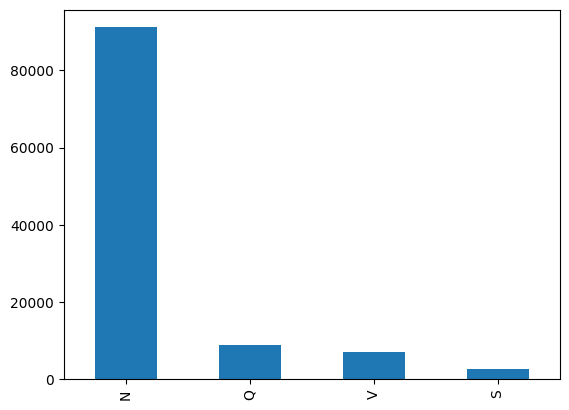

N    91080
Q     8816
V     7150
S     2702
Name: count, dtype: int64


c:\Users\hari\Desktop\workspace\ecg_arrhythmia\tasks.py:927: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hari\Desktop\workspace\ecg_arrhythmia\tasks.py:927: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hari\Desktop\workspace\ecg_arrhythmia\tasks.py:927: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\IPython\co

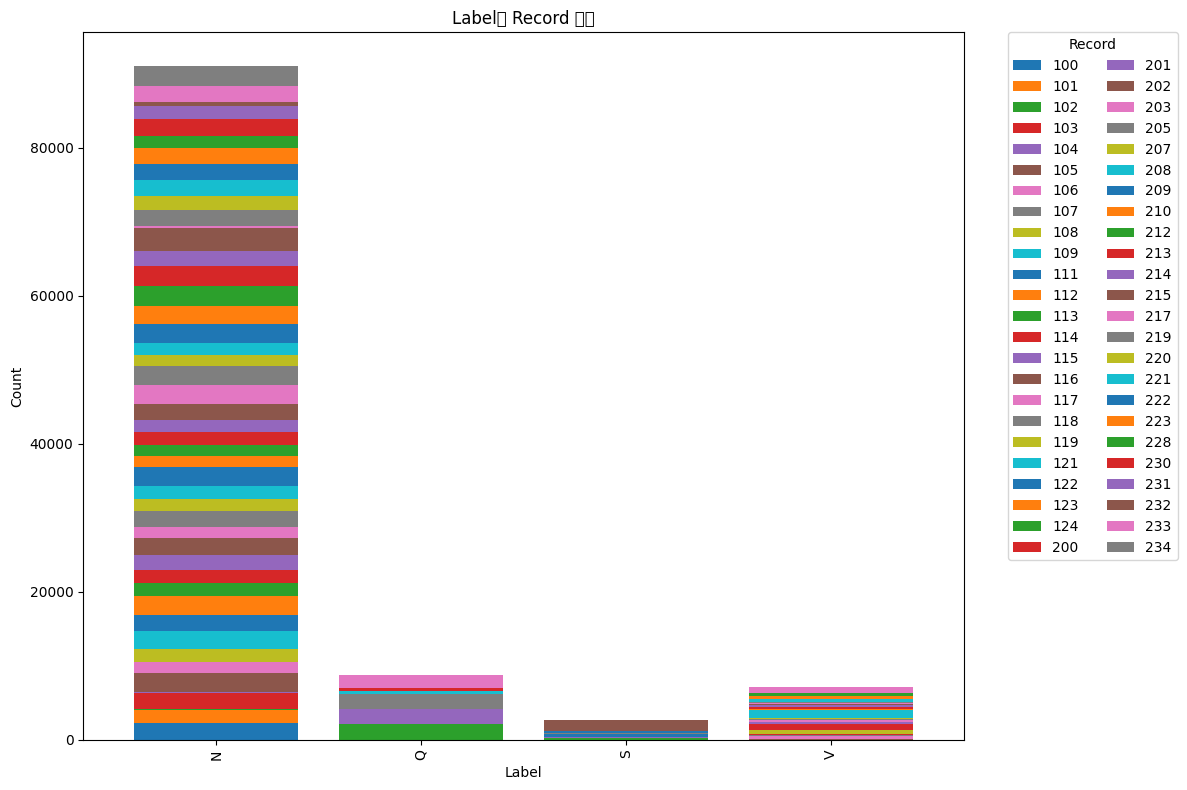

In [5]:
## plotting
label_hist(y)
label_record_hist(y, records)
# get_label_record_ratio(y, records) # label별 record 비율 desc 으로 출력

Epoch 1/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/step - accuracy: 0.7476 - loss: nan - val_accuracy: 0.8969 - val_loss: nan
Epoch 2/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9182 - loss: nan - val_accuracy: 0.9026 - val_loss: nan
Epoch 3/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9306 - loss: nan - val_accuracy: 0.9102 - val_loss: nan
Epoch 4/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.9356 - loss: nan - val_accuracy: 0.9391 - val_loss: nan
Epoch 5/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9422 - loss: nan - val_accuracy: 0.9455 - val_loss: nan
Epoch 6/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9443 - loss: nan - val_accuracy: 0.9445 - val_loss: nan
Epoch 7/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9464 - loss: nan - val_accuracy: 0.9513 - val_loss: nan
Epoch 8/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9483 - loss: nan - val_accuracy: 0.8538 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

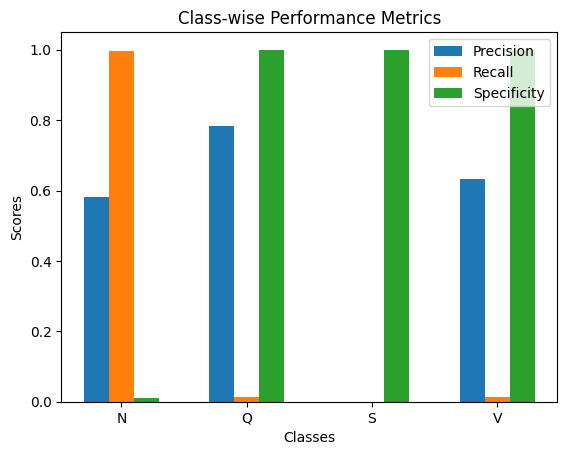

Epoch 1/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 57s 23ms/step - accuracy: 0.7351 - loss: nan - val_accuracy: 0.9098 - val_loss: nan
Epoch 2/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9209 - loss: nan - val_accuracy: 0.8675 - val_loss: nan
Epoch 3/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9353 - loss: nan - val_accuracy: 0.8995 - val_loss: nan
Epoch 4/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9417 - loss: nan - val_accuracy: 0.8895 - val_loss: nan
Epoch 5/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9449 - loss: nan - val_accuracy: 0.8452 - val_loss: nan
Epoch 6/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9505 - loss: nan - val_accuracy: 0.8912 - val_loss: nan
Epoch 7/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9499 - loss: nan - val_accuracy: 0.8906 - val_loss: nan
Epoch 8/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9522 - loss: nan - val_accuracy: 0.8991 - val_lo

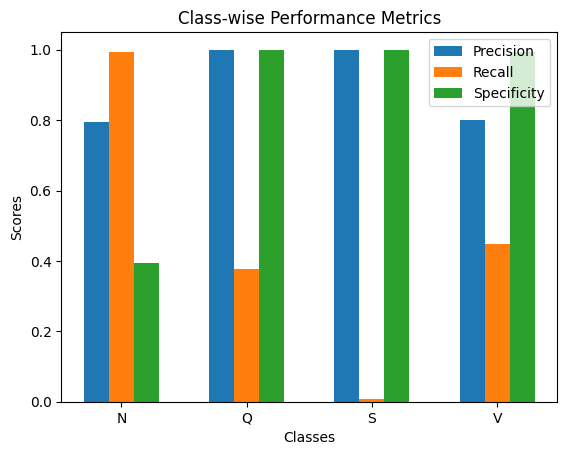

Epoch 1/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.7601 - loss: 2.1678 - val_accuracy: 0.4875 - val_loss: 1.3632
Epoch 2/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9178 - loss: 0.3548 - val_accuracy: 0.7073 - val_loss: 0.9792
Epoch 3/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9306 - loss: 0.2898 - val_accuracy: 0.6719 - val_loss: 1.2909
Epoch 4/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9355 - loss: 0.2688 - val_accuracy: 0.6965 - val_loss: 0.9995
Epoch 5/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9396 - loss: 0.2459 - val_accuracy: 0.7074 - val_loss: 1.3485
Epoch 6/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9408 - loss: 0.2378 - val_accuracy: 0.8086 - val_loss: 0.7307
Epoch 7/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9451 - loss: 0.2262 - val_accuracy: 0.8571 - val_loss: 0.4801
Epoch 8/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9469 -

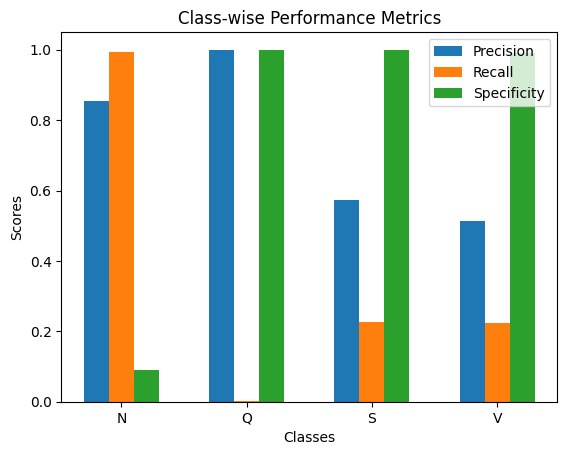

Epoch 1/50
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.7570 - loss: nan - val_accuracy: 0.9416 - val_loss: nan
Epoch 2/50
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.9398 - loss: nan - val_accuracy: 0.8266 - val_loss: nan
Epoch 3/50
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - accuracy: 0.9490 - loss: nan - val_accuracy: 0.8214 - val_loss: nan
Epoch 4/50
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - accuracy: 0.9528 - loss: nan - val_accuracy: 0.8315 - val_loss: nan
Epoch 5/50
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - accuracy: 0.9561 - loss: nan - val_accuracy: 0.9381 - val_loss: nan
Epoch 6/50
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.9590 - loss: nan - val_accuracy: 0.9244 - val_loss: nan
Epoch 7/50
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.9606 - loss: nan - val_accuracy: 0.9469 - val_loss: nan
Epoch 8/50
2119/2119 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.9608 - loss: nan - val_accuracy: 0.9327 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

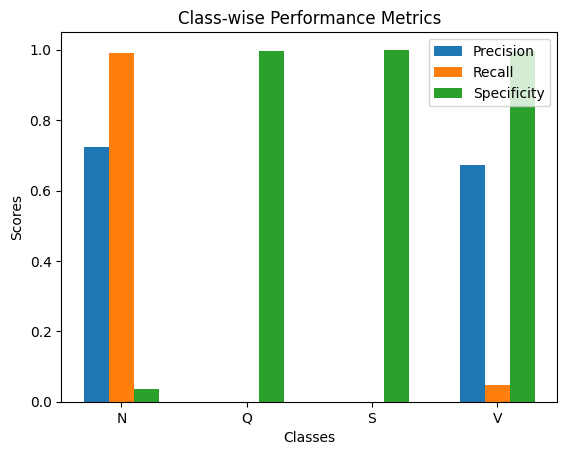

Epoch 1/50
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - accuracy: 0.7214 - loss: nan - val_accuracy: 0.7440 - val_loss: nan
Epoch 2/50
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9220 - loss: nan - val_accuracy: 0.7443 - val_loss: nan
Epoch 3/50
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9344 - loss: nan - val_accuracy: 0.9250 - val_loss: nan
Epoch 4/50
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9439 - loss: nan - val_accuracy: 0.9247 - val_loss: nan
Epoch 5/50
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9464 - loss: nan - val_accuracy: 0.8005 - val_loss: nan
Epoch 6/50
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9486 - loss: nan - val_accuracy: 0.9268 - val_loss: nan
Epoch 7/50
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9505 - loss: nan - val_accuracy: 0.9053 - val_loss: nan
Epoch 8/50
2208/2208 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9523 - loss: nan - val_accuracy: 0.9130 - val_lo

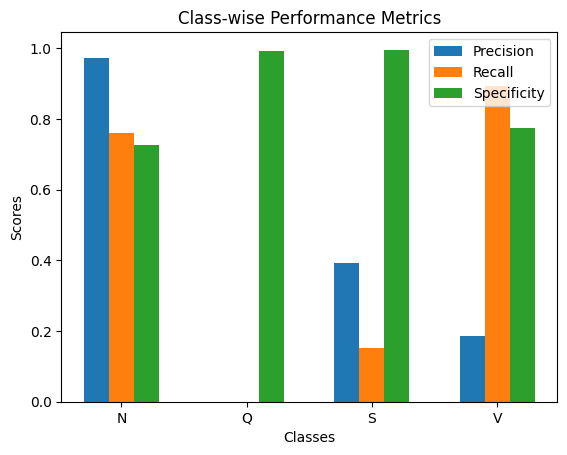

Epoch 1/50
2306/2306 ━━━━━━━━━━━━━━━━━━━━ 49s 20ms/step - accuracy: 0.7165 - loss: nan - val_accuracy: 0.8932 - val_loss: nan
Epoch 2/50
2306/2306 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9177 - loss: nan - val_accuracy: 0.8263 - val_loss: nan
Epoch 3/50
2306/2306 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9329 - loss: nan - val_accuracy: 0.8686 - val_loss: nan
Epoch 4/50
2306/2306 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9384 - loss: nan - val_accuracy: 0.7443 - val_loss: nan
Epoch 5/50
2306/2306 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9432 - loss: nan - val_accuracy: 0.8569 - val_loss: nan
Epoch 6/50
2306/2306 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9445 - loss: nan - val_accuracy: 0.8180 - val_loss: nan
Epoch 7/50
2306/2306 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9475 - loss: nan - val_accuracy: 0.8550 - val_loss: nan
Epoch 8/50
2306/2306 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9485 - loss: nan - val_accuracy: 0.8203 - val_lo

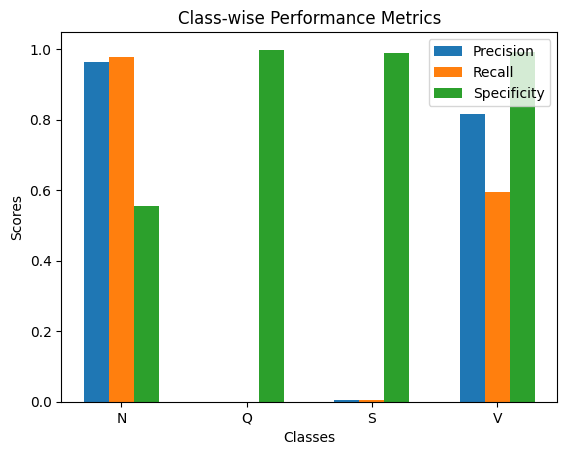

Epoch 1/50
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 49s 21ms/step - accuracy: 0.7353 - loss: nan - val_accuracy: 0.9099 - val_loss: nan
Epoch 2/50
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9356 - loss: nan - val_accuracy: 0.7222 - val_loss: nan
Epoch 3/50
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9445 - loss: nan - val_accuracy: 0.8910 - val_loss: nan
Epoch 4/50
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9485 - loss: nan - val_accuracy: 0.9225 - val_loss: nan
Epoch 5/50
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9529 - loss: nan - val_accuracy: 0.7633 - val_loss: nan
Epoch 6/50
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9549 - loss: nan - val_accuracy: 0.9071 - val_loss: nan
Epoch 7/50
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9547 - loss: nan - val_accuracy: 0.9025 - val_loss: nan
Epoch 8/50
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9575 - loss: nan - val_accuracy: 0.8368 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

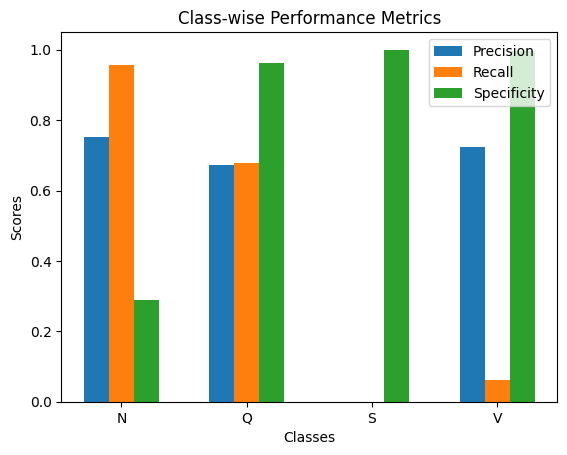

Epoch 1/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 48s 21ms/step - accuracy: 0.7336 - loss: nan - val_accuracy: 0.6859 - val_loss: nan
Epoch 2/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.9079 - loss: nan - val_accuracy: 0.7814 - val_loss: nan
Epoch 3/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.9232 - loss: nan - val_accuracy: 0.7071 - val_loss: nan
Epoch 4/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.9332 - loss: nan - val_accuracy: 0.6998 - val_loss: nan
Epoch 5/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9384 - loss: nan - val_accuracy: 0.7244 - val_loss: nan
Epoch 6/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9425 - loss: nan - val_accuracy: 0.7848 - val_loss: nan
Epoch 7/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9431 - loss: nan - val_accuracy: 0.7407 - val_loss: nan
Epoch 8/50
2116/2116 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.9436 - loss: nan - val_accuracy: 0.8022 - val_lo

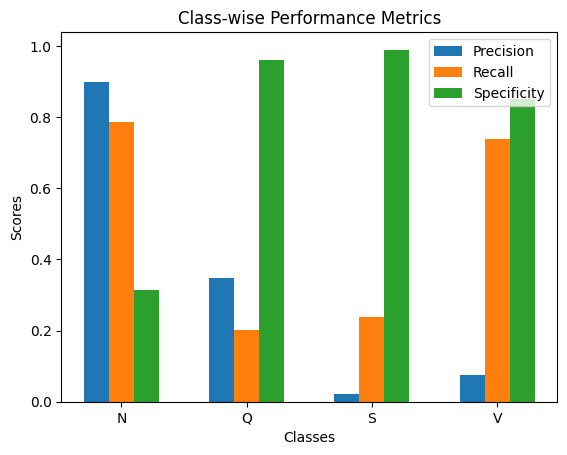

Epoch 1/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.7117 - loss: nan - val_accuracy: 0.8118 - val_loss: nan
Epoch 2/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.8980 - loss: nan - val_accuracy: 0.8382 - val_loss: nan
Epoch 3/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.9193 - loss: nan - val_accuracy: 0.8966 - val_loss: nan
Epoch 4/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.9269 - loss: nan - val_accuracy: 0.9051 - val_loss: nan
Epoch 5/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.9347 - loss: nan - val_accuracy: 0.9158 - val_loss: nan
Epoch 6/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.9390 - loss: nan - val_accuracy: 0.8137 - val_loss: nan
Epoch 7/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.9414 - loss: nan - val_accuracy: 0.8517 - val_loss: nan
Epoch 8/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9425 - loss: nan - val_accuracy: 0.8415 - val_lo

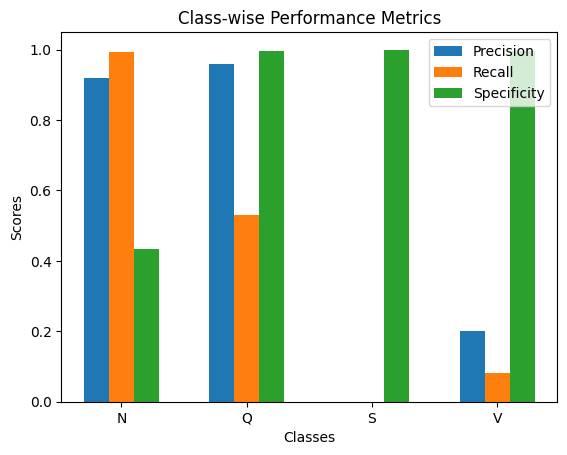

Epoch 1/50
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.7404 - loss: 2.3805 - val_accuracy: 0.6944 - val_loss: 73.2108
Epoch 2/50
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9254 - loss: 0.3437 - val_accuracy: 0.6934 - val_loss: 0.7833
Epoch 3/50
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9315 - loss: 0.3024 - val_accuracy: 0.5842 - val_loss: 1.2415
Epoch 4/50
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9395 - loss: 0.2668 - val_accuracy: 0.7306 - val_loss: 0.7896
Epoch 5/50
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9448 - loss: 0.2464 - val_accuracy: 0.8875 - val_loss: 0.3805
Epoch 6/50
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9452 - loss: 0.2414 - val_accuracy: 0.8646 - val_loss: 0.3893
Epoch 7/50
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9493 - loss: 0.2209 - val_accuracy: 0.9139 - val_loss: 0.2854
Epoch 8/50
2154/2154 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9528 

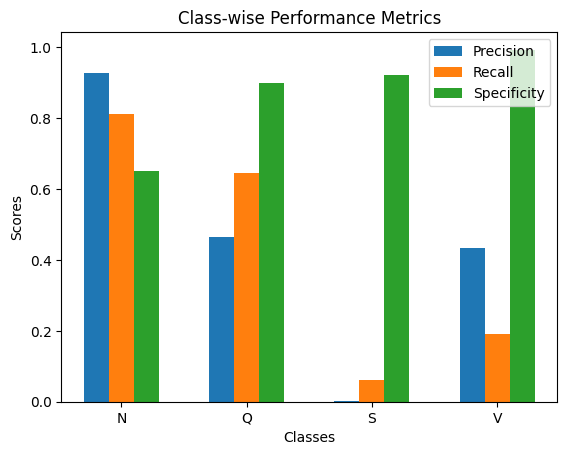

Epoch 1/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.7528 - loss: 2.2886 - val_accuracy: 0.7839 - val_loss: 1.1830
Epoch 2/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9318 - loss: 0.3291 - val_accuracy: 0.8317 - val_loss: 0.6056
Epoch 3/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9404 - loss: 0.2750 - val_accuracy: 0.8096 - val_loss: 0.7032
Epoch 4/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9474 - loss: 0.2390 - val_accuracy: 0.8748 - val_loss: 0.4992
Epoch 5/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9475 - loss: 0.2328 - val_accuracy: 0.8243 - val_loss: 0.7973
Epoch 6/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9505 - loss: 0.2203 - val_accuracy: 0.8152 - val_loss: 0.7523
Epoch 7/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9542 - loss: 0.2035 - val_accuracy: 0.8191 - val_loss: 0.7026
Epoch 8/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9592 -

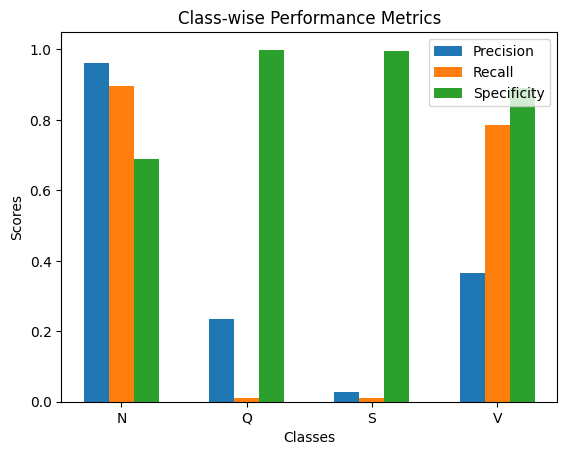

Epoch 1/50
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.7549 - loss: 2.0914 - val_accuracy: 0.6100 - val_loss: 1.8540
Epoch 2/50
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9303 - loss: 0.3121 - val_accuracy: 0.6977 - val_loss: 1.6637
Epoch 3/50
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9423 - loss: 0.2589 - val_accuracy: 0.7351 - val_loss: 1.8171
Epoch 4/50
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9433 - loss: 0.2460 - val_accuracy: 0.7055 - val_loss: 1.9998
Epoch 5/50
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9458 - loss: 0.2304 - val_accuracy: 0.6387 - val_loss: 2.7478
Epoch 6/50
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9453 - loss: 0.2243 - val_accuracy: 0.6257 - val_loss: 1.4949
Epoch 7/50
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9495 - loss: 0.2119 - val_accuracy: 0.6802 - val_loss: 1.0863
Epoch 8/50
2261/2261 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9535 -

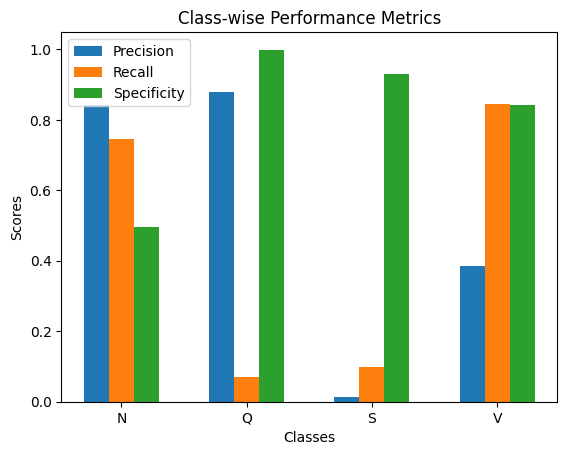

Epoch 1/50
2384/2384 ━━━━━━━━━━━━━━━━━━━━ 59s 23ms/step - accuracy: 0.7200 - loss: nan - val_accuracy: 0.8667 - val_loss: nan
Epoch 2/50
2384/2384 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.9222 - loss: nan - val_accuracy: 0.7969 - val_loss: nan
Epoch 3/50
2384/2384 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.9320 - loss: nan - val_accuracy: 0.8739 - val_loss: nan
Epoch 4/50
2384/2384 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.9393 - loss: nan - val_accuracy: 0.9002 - val_loss: nan
Epoch 5/50
2384/2384 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.9432 - loss: nan - val_accuracy: 0.9022 - val_loss: nan
Epoch 6/50
2384/2384 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.9484 - loss: nan - val_accuracy: 0.8475 - val_loss: nan
Epoch 7/50
2384/2384 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.9502 - loss: nan - val_accuracy: 0.8912 - val_loss: nan
Epoch 8/50
2384/2384 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.9503 - loss: nan - val_accuracy: 0.8315 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

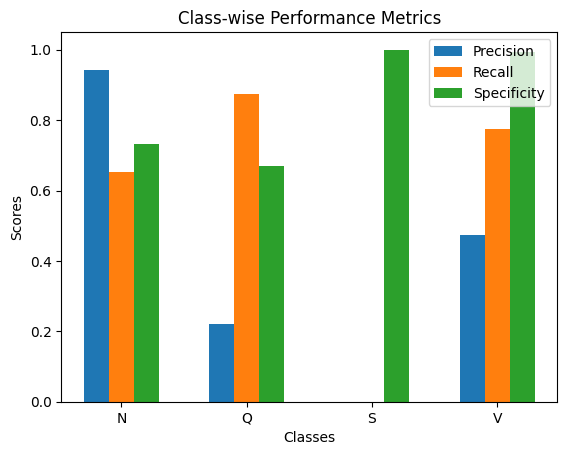

Epoch 1/50
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 56s 23ms/step - accuracy: 0.7246 - loss: nan - val_accuracy: 0.6608 - val_loss: nan
Epoch 2/50
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.9154 - loss: nan - val_accuracy: 0.6562 - val_loss: nan
Epoch 3/50
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.9310 - loss: nan - val_accuracy: 0.6291 - val_loss: nan
Epoch 4/50
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.9395 - loss: nan - val_accuracy: 0.6518 - val_loss: nan
Epoch 5/50
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.9417 - loss: nan - val_accuracy: 0.6560 - val_loss: nan
Epoch 6/50
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.9451 - loss: nan - val_accuracy: 0.6709 - val_loss: nan
Epoch 7/50
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.9488 - loss: nan - val_accuracy: 0.6475 - val_loss: nan
Epoch 8/50
2289/2289 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.9505 - loss: nan - val_accuracy: 0.6924 - val_lo

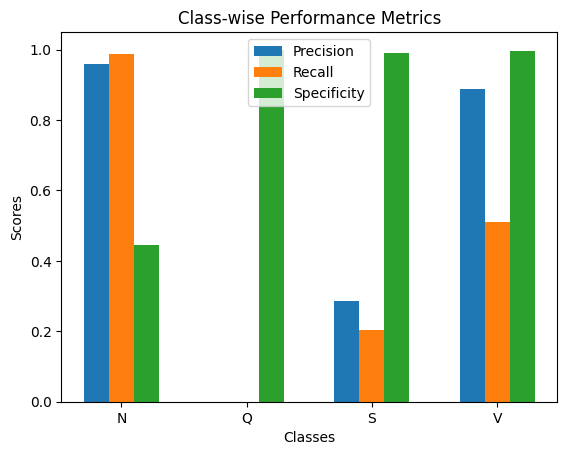

Epoch 1/50
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 55s 22ms/step - accuracy: 0.7649 - loss: 2.1238 - val_accuracy: 0.6167 - val_loss: 1.6777
Epoch 2/50
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.9145 - loss: 0.3384 - val_accuracy: 0.6629 - val_loss: 1.3396
Epoch 3/50
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.9296 - loss: 0.2831 - val_accuracy: 0.7592 - val_loss: 1.1255
Epoch 4/50
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9368 - loss: 0.2552 - val_accuracy: 0.6957 - val_loss: 2.0904
Epoch 5/50
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9434 - loss: 0.2287 - val_accuracy: 0.6419 - val_loss: 1.3892
Epoch 6/50
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - accuracy: 0.9459 - loss: 0.2182 - val_accuracy: 0.6486 - val_loss: 1.4649
Epoch 7/50
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9468 - loss: 0.2135 - val_accuracy: 0.6525 - val_loss: 1.4801
Epoch 8/50
2298/2298 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9501 -

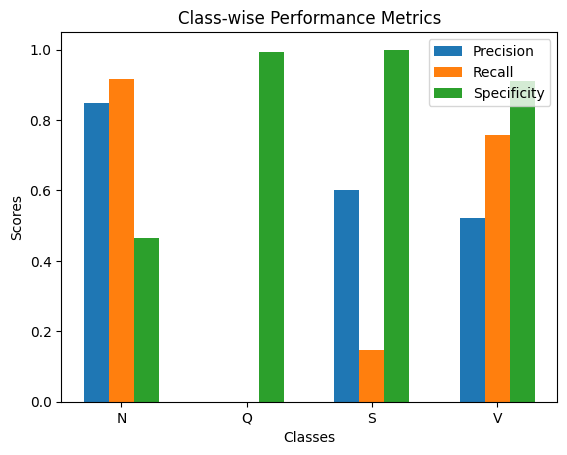

Epoch 1/50
2248/2248 ━━━━━━━━━━━━━━━━━━━━ 58s 24ms/step - accuracy: 0.7032 - loss: nan - val_accuracy: 0.9540 - val_loss: nan
Epoch 2/50
2248/2248 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9086 - loss: nan - val_accuracy: 0.9533 - val_loss: nan
Epoch 3/50
2248/2248 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9242 - loss: nan - val_accuracy: 0.8929 - val_loss: nan
Epoch 4/50
2248/2248 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9234 - loss: nan - val_accuracy: 0.7580 - val_loss: nan
Epoch 5/50
2248/2248 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9299 - loss: nan - val_accuracy: 0.8151 - val_loss: nan
Epoch 6/50
2248/2248 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9337 - loss: nan - val_accuracy: 0.8315 - val_loss: nan
Epoch 7/50
2248/2248 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9370 - loss: nan - val_accuracy: 0.9072 - val_loss: nan
Epoch 8/50
2248/2248 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9382 - loss: nan - val_accuracy: 0.9243 - val_lo

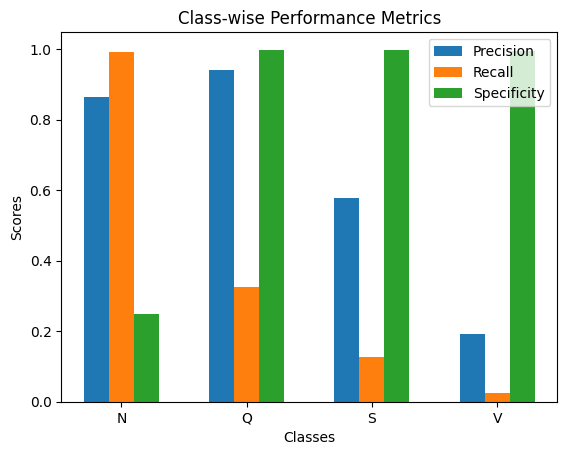

Epoch 1/50
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.7665 - loss: 2.2287 - val_accuracy: 0.6886 - val_loss: 1.3541
Epoch 2/50
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9211 - loss: 0.3259 - val_accuracy: 0.7446 - val_loss: 1.0505
Epoch 3/50
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9294 - loss: 0.2811 - val_accuracy: 0.7683 - val_loss: 1.1017
Epoch 4/50
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 48s 21ms/step - accuracy: 0.9289 - loss: 0.2750 - val_accuracy: 0.6481 - val_loss: 1.0913
Epoch 5/50
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9333 - loss: 0.2631 - val_accuracy: 0.7992 - val_loss: 0.9227
Epoch 6/50
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 48s 21ms/step - accuracy: 0.9331 - loss: 0.2670 - val_accuracy: 0.7563 - val_loss: 1.0529
Epoch 7/50
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9329 - loss: 0.2600 - val_accuracy: 0.7432 - val_loss: 0.9218
Epoch 8/50
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9379 -

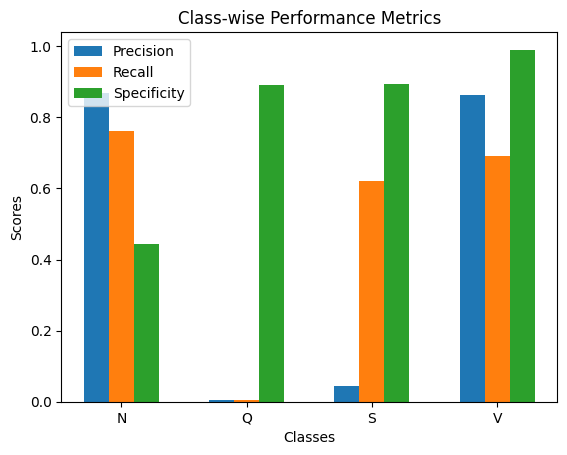

Epoch 1/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 54s 22ms/step - accuracy: 0.7602 - loss: 2.2449 - val_accuracy: 0.9182 - val_loss: 0.7429
Epoch 2/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9322 - loss: 0.3027 - val_accuracy: 0.8778 - val_loss: 0.5935
Epoch 3/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9431 - loss: 0.2550 - val_accuracy: 0.8790 - val_loss: 0.5739
Epoch 4/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9483 - loss: 0.2338 - val_accuracy: 0.8263 - val_loss: 0.6390
Epoch 5/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9492 - loss: 0.2260 - val_accuracy: 0.9173 - val_loss: 0.4569
Epoch 6/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9539 - loss: 0.2066 - val_accuracy: 0.9143 - val_loss: 0.4558
Epoch 7/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9542 - loss: 0.2019 - val_accuracy: 0.8858 - val_loss: 0.5422
Epoch 8/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9543 -

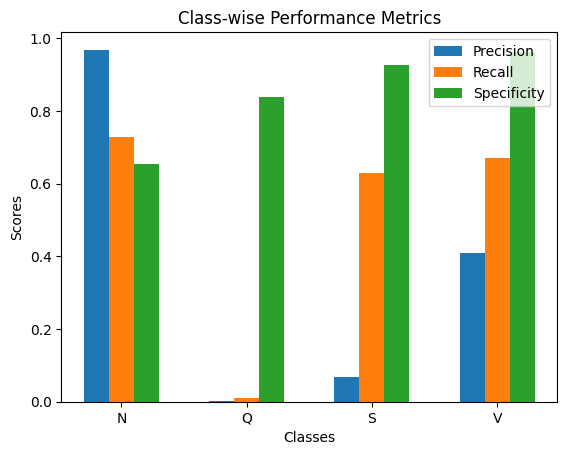

Epoch 1/50
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 58s 24ms/step - accuracy: 0.7334 - loss: nan - val_accuracy: 0.8810 - val_loss: nan
Epoch 2/50
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9271 - loss: nan - val_accuracy: 0.7021 - val_loss: nan
Epoch 3/50
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9339 - loss: nan - val_accuracy: 0.7334 - val_loss: nan
Epoch 4/50
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9419 - loss: nan - val_accuracy: 0.8844 - val_loss: nan
Epoch 5/50
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9453 - loss: nan - val_accuracy: 0.8611 - val_loss: nan
Epoch 6/50
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9474 - loss: nan - val_accuracy: 0.8353 - val_loss: nan
Epoch 7/50
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9497 - loss: nan - val_accuracy: 0.8882 - val_loss: nan
Epoch 8/50
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9533 - loss: nan - val_accuracy: 0.8906 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

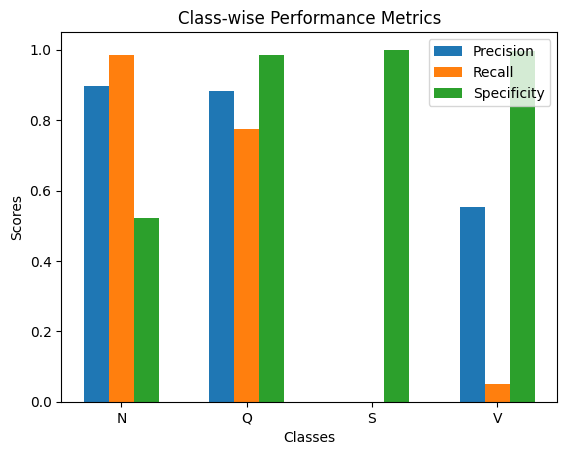

Epoch 1/50
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 59s 25ms/step - accuracy: 0.7589 - loss: nan - val_accuracy: 0.7310 - val_loss: nan
Epoch 2/50
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9271 - loss: nan - val_accuracy: 0.7963 - val_loss: nan
Epoch 3/50
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9413 - loss: nan - val_accuracy: 0.8213 - val_loss: nan
Epoch 4/50
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9456 - loss: nan - val_accuracy: 0.8630 - val_loss: nan
Epoch 5/50
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9497 - loss: nan - val_accuracy: 0.8005 - val_loss: nan
Epoch 6/50
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9502 - loss: nan - val_accuracy: 0.8789 - val_loss: nan
Epoch 7/50
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9537 - loss: nan - val_accuracy: 0.8787 - val_loss: nan
Epoch 8/50
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9543 - loss: nan - val_accuracy: 0.8554 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

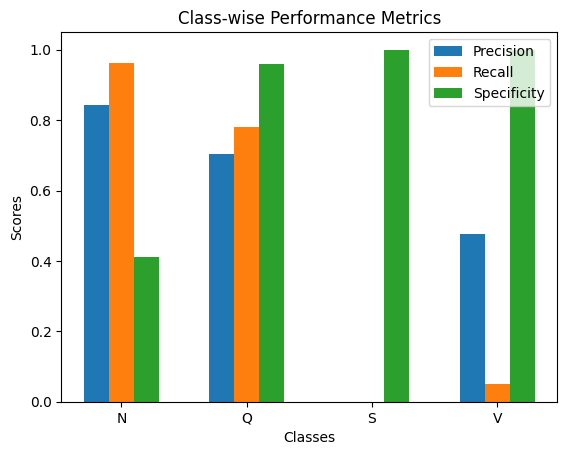

Epoch 1/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 60s 25ms/step - accuracy: 0.7091 - loss: nan - val_accuracy: 0.8557 - val_loss: nan
Epoch 2/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - accuracy: 0.8974 - loss: nan - val_accuracy: 0.9010 - val_loss: nan
Epoch 3/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - accuracy: 0.9154 - loss: nan - val_accuracy: 0.8832 - val_loss: nan
Epoch 4/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - accuracy: 0.9241 - loss: nan - val_accuracy: 0.8629 - val_loss: nan
Epoch 5/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - accuracy: 0.9289 - loss: nan - val_accuracy: 0.8961 - val_loss: nan
Epoch 6/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9320 - loss: nan - val_accuracy: 0.8503 - val_loss: nan
Epoch 7/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9338 - loss: nan - val_accuracy: 0.8606 - val_loss: nan
Epoch 8/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - accuracy: 0.9352 - loss: nan - val_accuracy: 0.8948 - val_lo

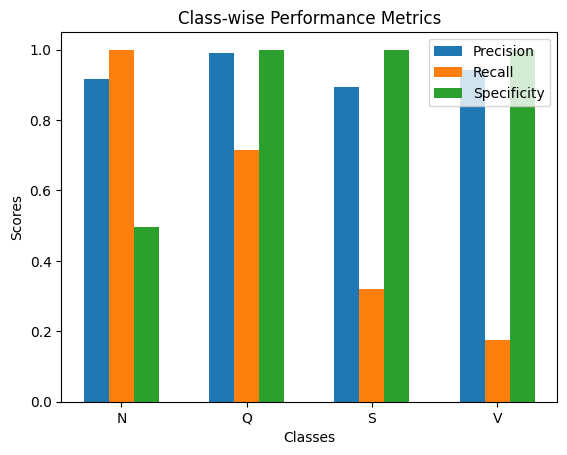

Epoch 1/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.7753 - loss: 2.2416 - val_accuracy: 0.8414 - val_loss: 0.7253
Epoch 2/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - accuracy: 0.9307 - loss: 0.3354 - val_accuracy: 0.7932 - val_loss: 0.7506
Epoch 3/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - accuracy: 0.9390 - loss: 0.2785 - val_accuracy: 0.8170 - val_loss: 0.5520
Epoch 4/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - accuracy: 0.9406 - loss: 0.2584 - val_accuracy: 0.8666 - val_loss: 0.4613
Epoch 5/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - accuracy: 0.9463 - loss: 0.2340 - val_accuracy: 0.8529 - val_loss: 0.4691
Epoch 6/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - accuracy: 0.9469 - loss: 0.2174 - val_accuracy: 0.8626 - val_loss: 0.5509
Epoch 7/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - accuracy: 0.9514 - loss: 0.2089 - val_accuracy: 0.8033 - val_loss: 0.7794
Epoch 8/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - accuracy: 0.9511 -

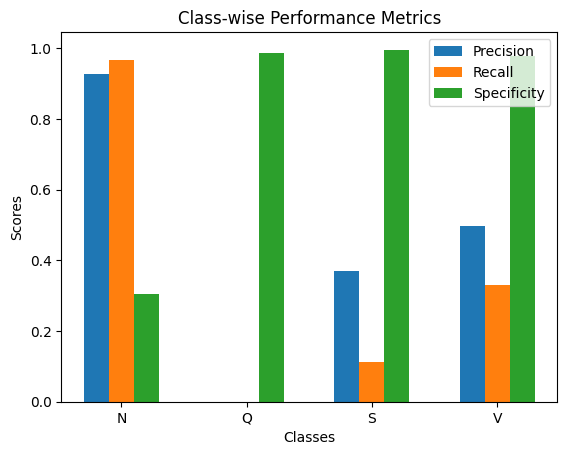

Epoch 1/50
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 58s 23ms/step - accuracy: 0.7295 - loss: nan - val_accuracy: 0.8475 - val_loss: nan
Epoch 2/50
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.9178 - loss: nan - val_accuracy: 0.8563 - val_loss: nan
Epoch 3/50
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.9275 - loss: nan - val_accuracy: 0.8473 - val_loss: nan
Epoch 4/50
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.9337 - loss: nan - val_accuracy: 0.8573 - val_loss: nan
Epoch 5/50
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.9393 - loss: nan - val_accuracy: 0.8640 - val_loss: nan
Epoch 6/50
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.9408 - loss: nan - val_accuracy: 0.8610 - val_loss: nan
Epoch 7/50
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.9422 - loss: nan - val_accuracy: 0.8540 - val_loss: nan
Epoch 8/50
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 54s 23ms/step - accuracy: 0.9457 - loss: nan - val_accuracy: 0.8616 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

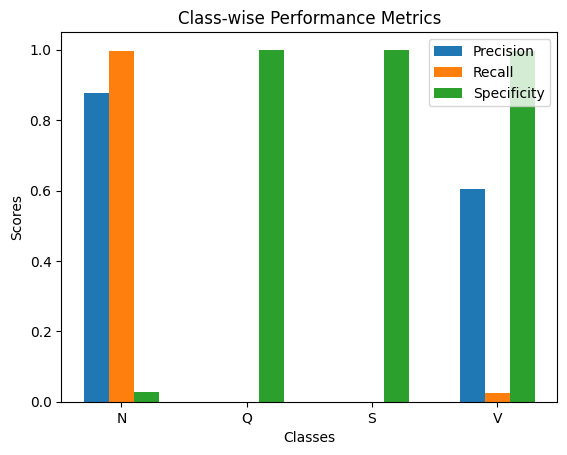

Epoch 1/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 60s 24ms/step - accuracy: 0.7601 - loss: 2.1598 - val_accuracy: 0.8299 - val_loss: 0.6560
Epoch 2/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9297 - loss: 0.3240 - val_accuracy: 0.8190 - val_loss: 0.6955
Epoch 3/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9413 - loss: 0.2656 - val_accuracy: 0.8146 - val_loss: 1.1461
Epoch 4/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9491 - loss: 0.2360 - val_accuracy: 0.8009 - val_loss: 0.6677
Epoch 5/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - accuracy: 0.9506 - loss: 0.2289 - val_accuracy: 0.7970 - val_loss: 0.6352
Epoch 6/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9540 - loss: 0.2074 - val_accuracy: 0.8091 - val_loss: 0.6731
Epoch 7/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9564 - loss: 0.1979 - val_accuracy: 0.7814 - val_loss: 0.8017
Epoch 8/50
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9554 -

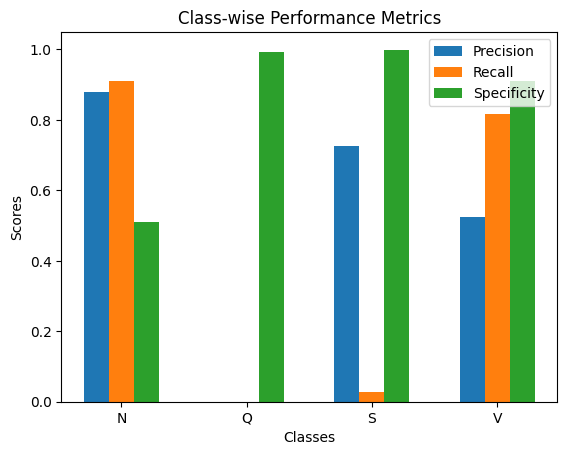

Epoch 1/50
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 59s 25ms/step - accuracy: 0.7212 - loss: nan - val_accuracy: 0.9191 - val_loss: nan
Epoch 2/50
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9191 - loss: nan - val_accuracy: 0.8877 - val_loss: nan
Epoch 3/50
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9265 - loss: nan - val_accuracy: 0.9175 - val_loss: nan
Epoch 4/50
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9331 - loss: nan - val_accuracy: 0.9294 - val_loss: nan
Epoch 5/50
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9352 - loss: nan - val_accuracy: 0.9190 - val_loss: nan
Epoch 6/50
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9404 - loss: nan - val_accuracy: 0.8831 - val_loss: nan
Epoch 7/50
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9428 - loss: nan - val_accuracy: 0.9287 - val_loss: nan
Epoch 8/50
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9469 - loss: nan - val_accuracy: 0.9404 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

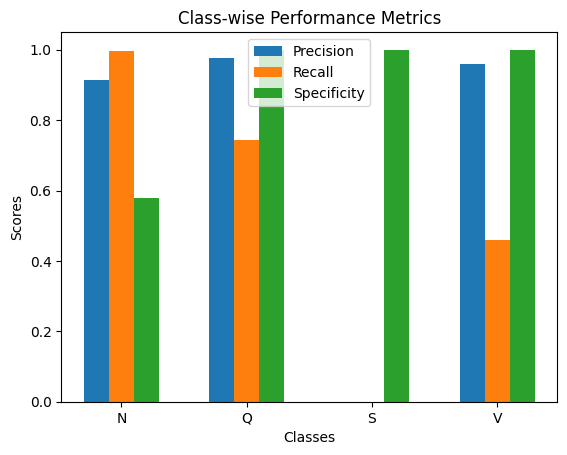

Epoch 1/50
2031/2031 ━━━━━━━━━━━━━━━━━━━━ 55s 25ms/step - accuracy: 0.7420 - loss: 2.3886 - val_accuracy: 0.8917 - val_loss: 0.4515
Epoch 2/50
2031/2031 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step - accuracy: 0.9143 - loss: 0.3674 - val_accuracy: 0.8657 - val_loss: 0.5505
Epoch 3/50
2031/2031 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step - accuracy: 0.9359 - loss: 0.2858 - val_accuracy: 0.8777 - val_loss: 0.4950
Epoch 4/50
2031/2031 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step - accuracy: 0.9396 - loss: 0.2689 - val_accuracy: 0.8634 - val_loss: 0.5253
Epoch 5/50
2031/2031 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step - accuracy: 0.9419 - loss: 0.2511 - val_accuracy: 0.8757 - val_loss: 0.4296
Epoch 6/50
2031/2031 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step - accuracy: 0.9461 - loss: 0.2345 - val_accuracy: 0.8199 - val_loss: 0.6605
Epoch 7/50
2031/2031 ━━━━━━━━━━━━━━━━━━━━ 50s 25ms/step - accuracy: 0.9499 - loss: 0.2144 - val_accuracy: 0.7703 - val_loss: 0.7917
Epoch 8/50
2031/2031 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step - accuracy: 0.9542 -

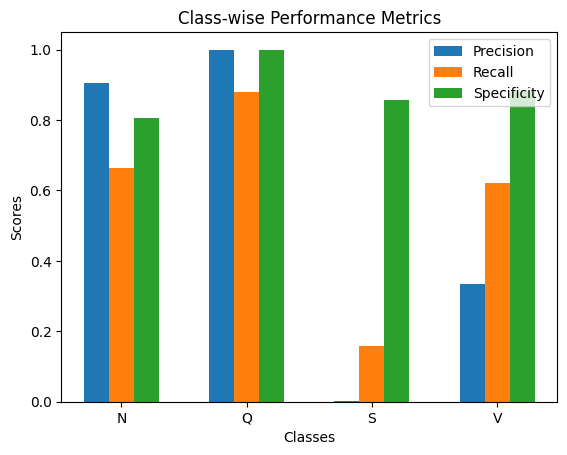

Epoch 1/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 61s 24ms/step - accuracy: 0.7296 - loss: nan - val_accuracy: 0.8335 - val_loss: nan
Epoch 2/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9168 - loss: nan - val_accuracy: 0.8304 - val_loss: nan
Epoch 3/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9323 - loss: nan - val_accuracy: 0.8943 - val_loss: nan
Epoch 4/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9382 - loss: nan - val_accuracy: 0.9215 - val_loss: nan
Epoch 5/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9418 - loss: nan - val_accuracy: 0.8991 - val_loss: nan
Epoch 6/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/step - accuracy: 0.9416 - loss: nan - val_accuracy: 0.9148 - val_loss: nan
Epoch 7/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/step - accuracy: 0.9469 - loss: nan - val_accuracy: 0.9072 - val_loss: nan
Epoch 8/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9474 - loss: nan - val_accuracy: 0.8985 - val_lo

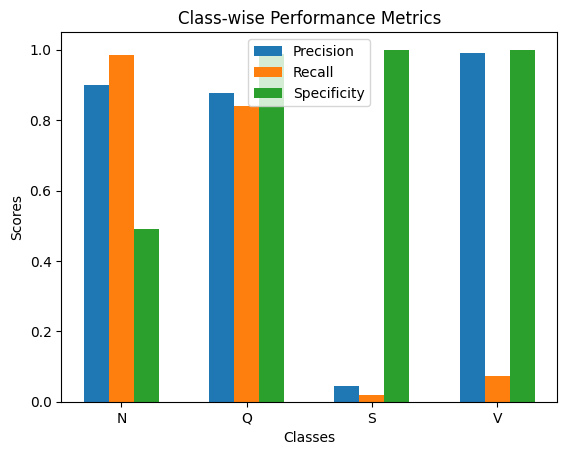

Epoch 1/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.7592 - loss: nan - val_accuracy: 0.8398 - val_loss: nan
Epoch 2/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9305 - loss: nan - val_accuracy: 0.8280 - val_loss: nan
Epoch 3/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9457 - loss: nan - val_accuracy: 0.7490 - val_loss: nan
Epoch 4/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9525 - loss: nan - val_accuracy: 0.6963 - val_loss: nan
Epoch 5/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9556 - loss: nan - val_accuracy: 0.8507 - val_loss: nan
Epoch 6/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9606 - loss: nan - val_accuracy: 0.8319 - val_loss: nan
Epoch 7/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9605 - loss: nan - val_accuracy: 0.8103 - val_loss: nan
Epoch 8/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9624 - loss: nan - val_accuracy: 0.7963 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

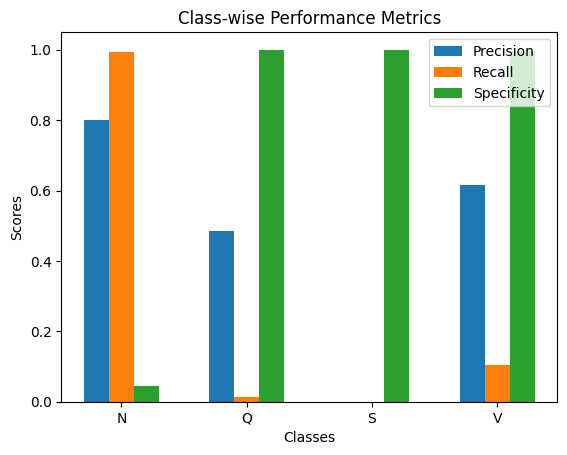

Epoch 1/50
2252/2252 ━━━━━━━━━━━━━━━━━━━━ 59s 25ms/step - accuracy: 0.7271 - loss: nan - val_accuracy: 0.8155 - val_loss: nan
Epoch 2/50
2252/2252 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9153 - loss: nan - val_accuracy: 0.9344 - val_loss: nan
Epoch 3/50
2252/2252 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9295 - loss: nan - val_accuracy: 0.8785 - val_loss: nan
Epoch 4/50
2252/2252 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9363 - loss: nan - val_accuracy: 0.8608 - val_loss: nan
Epoch 5/50
2252/2252 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9418 - loss: nan - val_accuracy: 0.9442 - val_loss: nan
Epoch 6/50
2252/2252 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9474 - loss: nan - val_accuracy: 0.8971 - val_loss: nan
Epoch 7/50
2252/2252 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9479 - loss: nan - val_accuracy: 0.8753 - val_loss: nan
Epoch 8/50
2252/2252 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9506 - loss: nan - val_accuracy: 0.8536 - val_lo

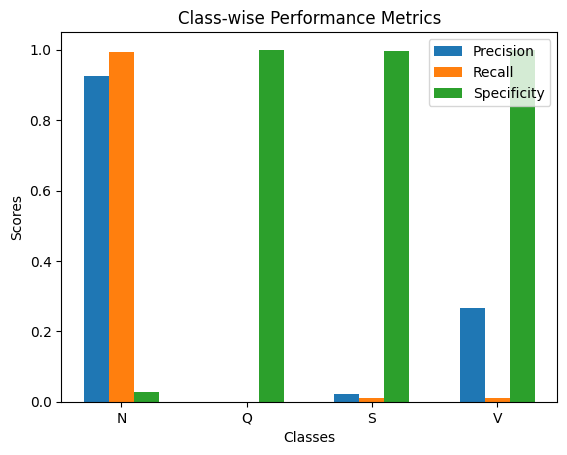

Epoch 1/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/step - accuracy: 0.7520 - loss: nan - val_accuracy: 0.9055 - val_loss: nan
Epoch 2/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9403 - loss: nan - val_accuracy: 0.8759 - val_loss: nan
Epoch 3/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9485 - loss: nan - val_accuracy: 0.8974 - val_loss: nan
Epoch 4/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9536 - loss: nan - val_accuracy: 0.8508 - val_loss: nan
Epoch 5/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9572 - loss: nan - val_accuracy: 0.8824 - val_loss: nan
Epoch 6/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9592 - loss: nan - val_accuracy: 0.8821 - val_loss: nan
Epoch 7/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9612 - loss: nan - val_accuracy: 0.5554 - val_loss: nan
Epoch 8/50
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9612 - loss: nan - val_accuracy: 0.8623 - val_lo

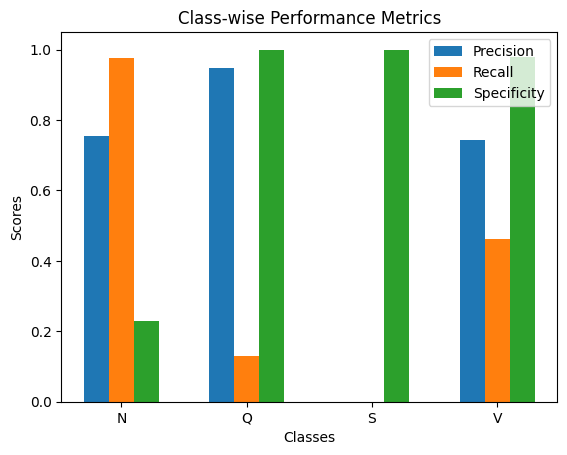

Epoch 1/50
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/step - accuracy: 0.7010 - loss: nan - val_accuracy: 0.8111 - val_loss: nan
Epoch 2/50
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9215 - loss: nan - val_accuracy: 0.7249 - val_loss: nan
Epoch 3/50
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9307 - loss: nan - val_accuracy: 0.8424 - val_loss: nan
Epoch 4/50
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9405 - loss: nan - val_accuracy: 0.8317 - val_loss: nan
Epoch 5/50
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9455 - loss: nan - val_accuracy: 0.8689 - val_loss: nan
Epoch 6/50
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9471 - loss: nan - val_accuracy: 0.7981 - val_loss: nan
Epoch 7/50
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9505 - loss: nan - val_accuracy: 0.9425 - val_loss: nan
Epoch 8/50
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9513 - loss: nan - val_accuracy: 0.7316 - val_lo

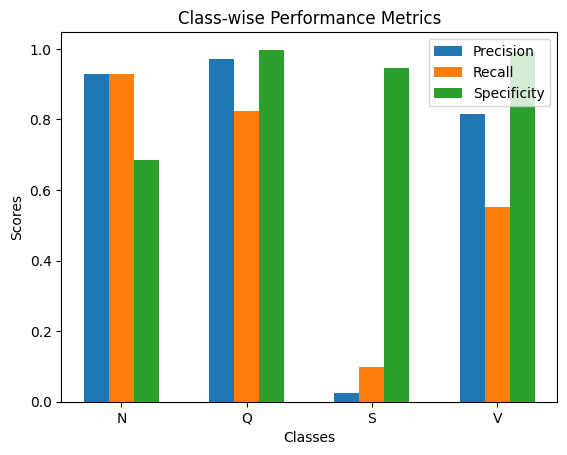

Epoch 1/50
2247/2247 ━━━━━━━━━━━━━━━━━━━━ 68s 28ms/step - accuracy: 0.7051 - loss: nan - val_accuracy: 0.9732 - val_loss: nan
Epoch 2/50
2247/2247 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - accuracy: 0.8977 - loss: nan - val_accuracy: 0.7758 - val_loss: nan
Epoch 3/50
2247/2247 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - accuracy: 0.9157 - loss: nan - val_accuracy: 0.9258 - val_loss: nan
Epoch 4/50
2247/2247 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - accuracy: 0.9233 - loss: nan - val_accuracy: 0.9072 - val_loss: nan
Epoch 5/50
2247/2247 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - accuracy: 0.9328 - loss: nan - val_accuracy: 0.9155 - val_loss: nan
Epoch 6/50
2247/2247 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - accuracy: 0.9361 - loss: nan - val_accuracy: 0.9643 - val_loss: nan
Epoch 7/50
2247/2247 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - accuracy: 0.9398 - loss: nan - val_accuracy: 0.9645 - val_loss: nan
Epoch 8/50
2247/2247 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - accuracy: 0.9422 - loss: nan - val_accuracy: 0.9001 - val_lo

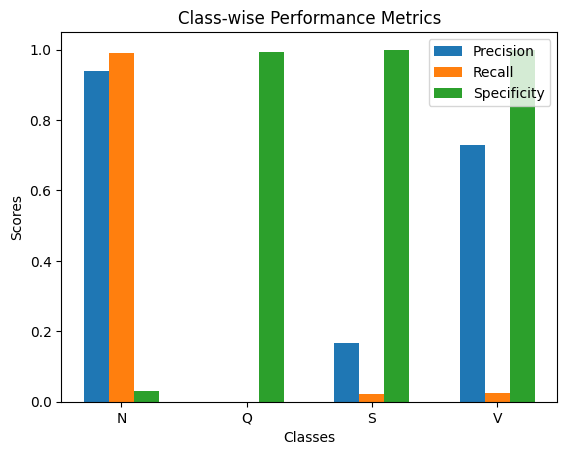

Epoch 1/50
2202/2202 ━━━━━━━━━━━━━━━━━━━━ 62s 27ms/step - accuracy: 0.7236 - loss: nan - val_accuracy: 0.7181 - val_loss: nan
Epoch 2/50
2202/2202 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9219 - loss: nan - val_accuracy: 0.8322 - val_loss: nan
Epoch 3/50
2202/2202 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9347 - loss: nan - val_accuracy: 0.7999 - val_loss: nan
Epoch 4/50
2202/2202 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9405 - loss: nan - val_accuracy: 0.8764 - val_loss: nan
Epoch 5/50
2202/2202 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9433 - loss: nan - val_accuracy: 0.8203 - val_loss: nan
Epoch 6/50
2202/2202 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9463 - loss: nan - val_accuracy: 0.8824 - val_loss: nan
Epoch 7/50
2202/2202 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9475 - loss: nan - val_accuracy: 0.6974 - val_loss: nan
Epoch 8/50
2202/2202 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9525 - loss: nan - val_accuracy: 0.8311 - val_lo

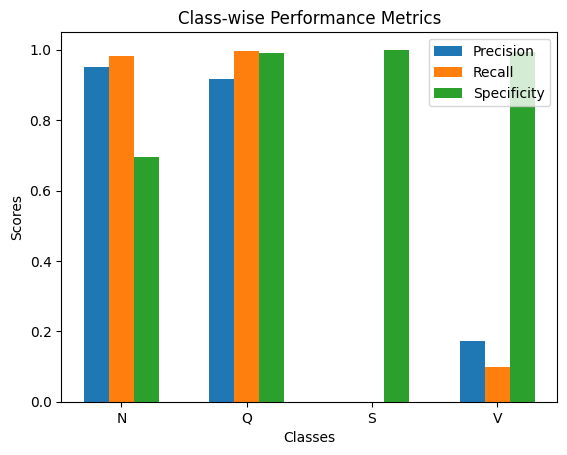

Epoch 1/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 65s 26ms/step - accuracy: 0.7211 - loss: nan - val_accuracy: 0.9413 - val_loss: nan
Epoch 2/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9257 - loss: nan - val_accuracy: 0.9625 - val_loss: nan
Epoch 3/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9327 - loss: nan - val_accuracy: 0.7337 - val_loss: nan
Epoch 4/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9379 - loss: nan - val_accuracy: 0.8017 - val_loss: nan
Epoch 5/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9411 - loss: nan - val_accuracy: 0.9730 - val_loss: nan
Epoch 6/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9458 - loss: nan - val_accuracy: 0.9647 - val_loss: nan
Epoch 7/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9463 - loss: nan - val_accuracy: 0.9160 - val_loss: nan
Epoch 8/50
2310/2310 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9495 - loss: nan - val_accuracy: 0.7223 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

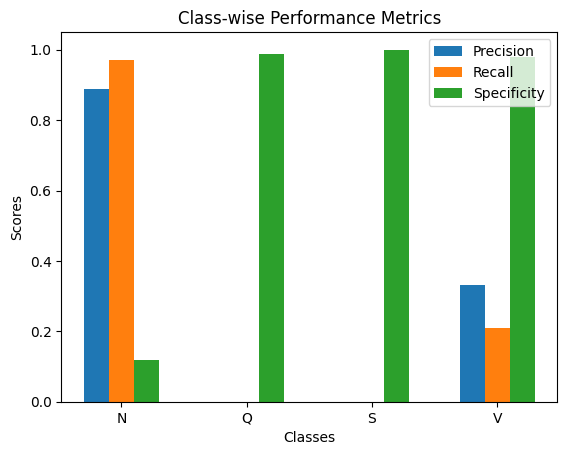

Epoch 1/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 62s 26ms/step - accuracy: 0.7520 - loss: 2.2304 - val_accuracy: 0.7079 - val_loss: 1.2442
Epoch 2/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9276 - loss: 0.3343 - val_accuracy: 0.8519 - val_loss: 0.5562
Epoch 3/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9396 - loss: 0.2870 - val_accuracy: 0.7221 - val_loss: 1.2446
Epoch 4/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9438 - loss: 0.2615 - val_accuracy: 0.7850 - val_loss: 0.8491
Epoch 5/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9472 - loss: 0.2439 - val_accuracy: 0.7637 - val_loss: 0.7870
Epoch 6/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9524 - loss: 0.2186 - val_accuracy: 0.6927 - val_loss: 0.8312
Epoch 7/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9556 - loss: 0.2073 - val_accuracy: 0.7584 - val_loss: 1.0699
Epoch 8/50
2266/2266 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9551 -

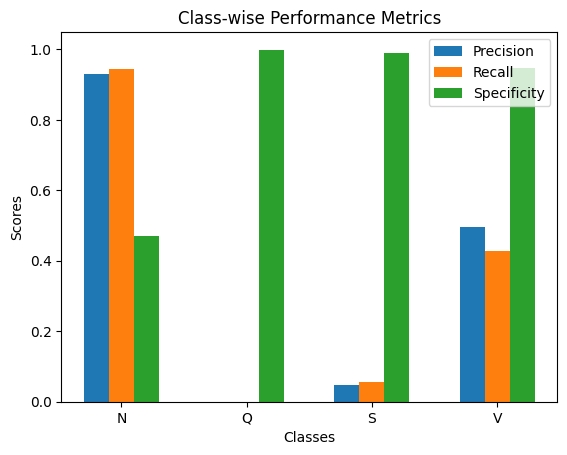

Epoch 1/50
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 63s 25ms/step - accuracy: 0.7483 - loss: nan - val_accuracy: 0.7659 - val_loss: nan
Epoch 2/50
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9221 - loss: nan - val_accuracy: 0.7042 - val_loss: nan
Epoch 3/50
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9325 - loss: nan - val_accuracy: 0.4843 - val_loss: nan
Epoch 4/50
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9383 - loss: nan - val_accuracy: 0.7794 - val_loss: nan
Epoch 5/50
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9435 - loss: nan - val_accuracy: 0.7711 - val_loss: nan
Epoch 6/50
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9469 - loss: nan - val_accuracy: 0.7479 - val_loss: nan
Epoch 7/50
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9502 - loss: nan - val_accuracy: 0.7942 - val_loss: nan
Epoch 8/50
2349/2349 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9521 - loss: nan - val_accuracy: 0.7760 - val_lo

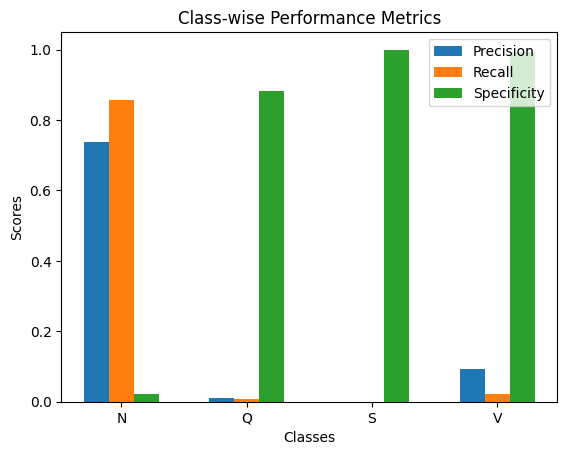

Epoch 1/50
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 62s 26ms/step - accuracy: 0.7585 - loss: nan - val_accuracy: 0.7564 - val_loss: nan
Epoch 2/50
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - accuracy: 0.9268 - loss: nan - val_accuracy: 0.8134 - val_loss: nan
Epoch 3/50
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - accuracy: 0.9347 - loss: nan - val_accuracy: 0.7924 - val_loss: nan
Epoch 4/50
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - accuracy: 0.9410 - loss: nan - val_accuracy: 0.7746 - val_loss: nan
Epoch 5/50
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - accuracy: 0.9414 - loss: nan - val_accuracy: 0.8044 - val_loss: nan
Epoch 6/50
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - accuracy: 0.9431 - loss: nan - val_accuracy: 0.8431 - val_loss: nan
Epoch 7/50
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 59s 26ms/step - accuracy: 0.9464 - loss: nan - val_accuracy: 0.8063 - val_loss: nan
Epoch 8/50
2244/2244 ━━━━━━━━━━━━━━━━━━━━ 59s 26ms/step - accuracy: 0.9474 - loss: nan - val_accuracy: 0.7801 - val_lo

c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

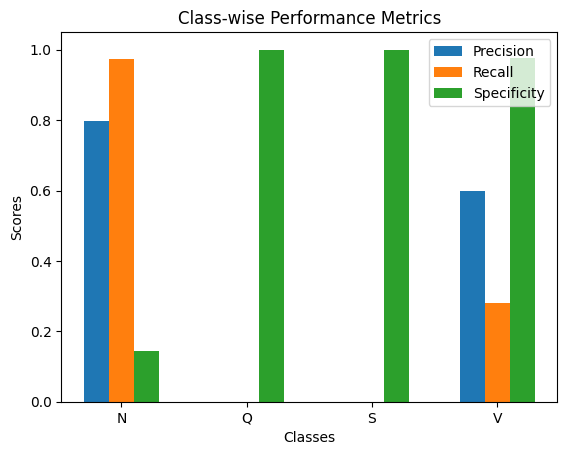

Epoch 1/50
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 64s 26ms/step - accuracy: 0.7427 - loss: nan - val_accuracy: 0.8172 - val_loss: nan
Epoch 2/50
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9202 - loss: nan - val_accuracy: 0.8003 - val_loss: nan
Epoch 3/50
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9345 - loss: nan - val_accuracy: 0.8034 - val_loss: nan
Epoch 4/50
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9401 - loss: nan - val_accuracy: 0.7575 - val_loss: nan
Epoch 5/50
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9466 - loss: nan - val_accuracy: 0.7171 - val_loss: nan
Epoch 6/50
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9496 - loss: nan - val_accuracy: 0.7536 - val_loss: nan
Epoch 7/50
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9520 - loss: nan - val_accuracy: 0.7893 - val_loss: nan
Epoch 8/50
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9548 - loss: nan - val_accuracy: 0.8138 - val_lo

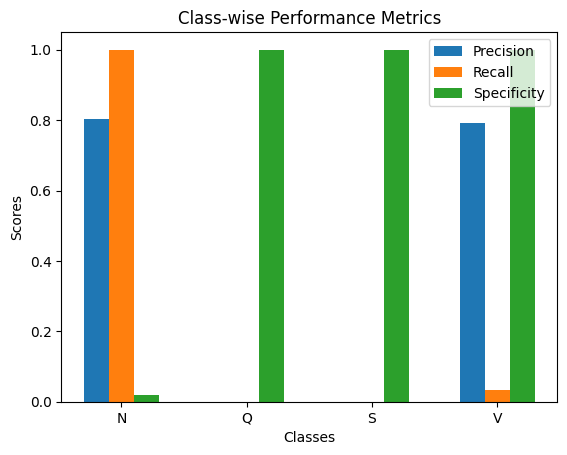

Epoch 1/50
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 63s 25ms/step - accuracy: 0.7058 - loss: nan - val_accuracy: 0.7513 - val_loss: nan
Epoch 2/50
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 61s 26ms/step - accuracy: 0.9060 - loss: nan - val_accuracy: 0.9067 - val_loss: nan
Epoch 3/50
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9189 - loss: nan - val_accuracy: 0.8968 - val_loss: nan
Epoch 4/50
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9273 - loss: nan - val_accuracy: 0.8266 - val_loss: nan
Epoch 5/50
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9270 - loss: nan - val_accuracy: 0.9036 - val_loss: nan
Epoch 6/50
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9339 - loss: nan - val_accuracy: 0.8718 - val_loss: nan
Epoch 7/50
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9352 - loss: nan - val_accuracy: 0.9362 - val_loss: nan
Epoch 8/50
2339/2339 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - accuracy: 0.9402 - loss: nan - val_accuracy: 0.9129 - val_lo

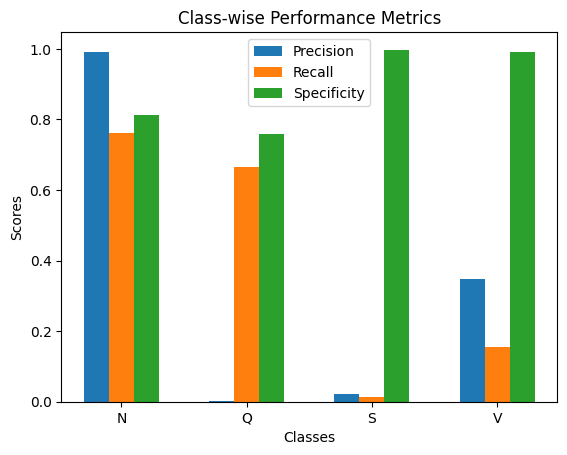

Epoch 1/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 62s 26ms/step - accuracy: 0.7426 - loss: nan - val_accuracy: 0.7073 - val_loss: nan
Epoch 2/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9302 - loss: nan - val_accuracy: 0.7217 - val_loss: nan
Epoch 3/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9435 - loss: nan - val_accuracy: 0.7257 - val_loss: nan
Epoch 4/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9499 - loss: nan - val_accuracy: 0.7191 - val_loss: nan
Epoch 5/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9560 - loss: nan - val_accuracy: 0.7260 - val_loss: nan
Epoch 6/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9591 - loss: nan - val_accuracy: 0.7127 - val_loss: nan
Epoch 7/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - accuracy: 0.9618 - loss: nan - val_accuracy: 0.6312 - val_loss: nan
Epoch 8/50
2270/2270 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9640 - loss: nan - val_accuracy: 0.5904 - val_lo

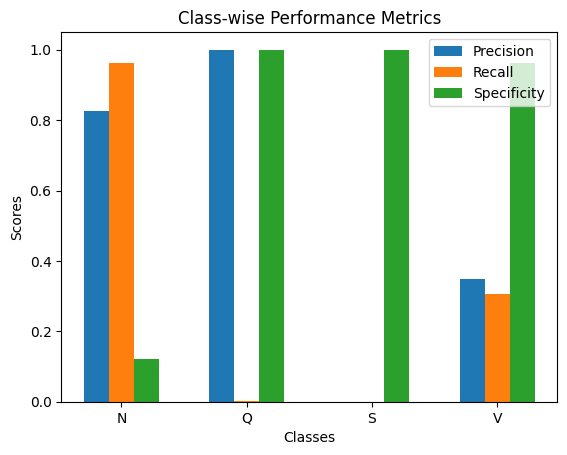

In [27]:
# metric_df를 담을 리스트 초기화
all_metrics = []
for seed in range(40):
    file_name = f'test_seed{seed}'
    # record 기준 data split
    # combine x1, x2 for split
    x1x2 = np.hstack((x1, x2))

    # data split stratified
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y, groups=records)):
    # sgkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y)):
        break    
    x1x2_train_val = x1x2[train_val_idx]
    y_train_val = y[train_val_idx]
    records_train_val = records[train_val_idx]

    # Train/Validation 데이터를 다시 StratifiedGroupKFold로 나누기
    sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val, groups=records_train_val):
    # sgkf_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val):
        break  # 첫 번째 split을 사용하여 Train/Validation 분할

    x1_train = x1x2_train_val[train_idx][:, :x1.shape[1]]
    x2_train = x1x2_train_val[train_idx][:, x1.shape[1]:]
    x1_val = x1x2_train_val[val_idx][:, :x1.shape[1]]
    x2_val = x1x2_train_val[val_idx][:, x1.shape[1]:]
    x1_test = x1x2[test_idx][:, :x1.shape[1]]
    x2_test = x1x2[test_idx][:, x1.shape[1]:]

    y_train = y_train_val[train_idx]
    y_val = y_train_val[val_idx]
    y_test = y[test_idx]

    # class weight 생성
    unique_labels = np.unique(y_train)
    # 'balanced' 모드는 각 클래스가 데이터셋에서 등장하는 비율에 반비례하도록 가중치 계산
    class_weights_array = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=unique_labels,
        y=y_train
    )

    # scikit-learn이 반환한 array를 {클래스: 가중치} 형태의 딕셔너리로 변환
    class_weights = {
        label: weight for label, weight in zip(unique_labels, class_weights_array)
    }



    # one-hot encoding
    y_train_oh, class_names = one_hot_encoder(y_train)
    y_val_oh, _ = one_hot_encoder(y_val)
    y_test_oh, _ = one_hot_encoder(y_test)
    # model initialization
    x1_shape = (x1_train.shape[1], 1)
    x2_shape = (x2_train.shape[1],)
    n_classes = y_train_oh.shape[1]
    model = CNNModel(x1_shape, x2_shape, n_classes)   
    # model training
    model.fit([x1_train, x2_train], y_train_oh, [x1_val, x2_val], y_val_oh, y_train, class_weight=class_weights)
    # model evaluation
    test_loss, test_accuracy = model.evaluate([x1_test,x2_test], y_test_oh)
    print(f"Test accuracy: {test_accuracy:.4f}")
    # prediction
    y_pred = model.predict([x1_test, x2_test])
    y_test = np.argmax(y_test_oh, axis=1)  

    # get precision, recall, f1-score, specificity
    precision, recall, f1, specificity = calc_metrics(y_test, y_pred, class_names)
    global_metrics = calc_global_metrics(y_test, y_pred)

    # report
    print(classification_report(y_test, y_pred, target_names=class_names))
    # get metric df
    metric_df = get_metric_df(precision, recall, f1, specificity, class_names)
    metric_df['seed'] = seed  # 각 seed 정보 추가
    print(metric_df)
    
    # 각 반복마다 생성된 metric_df를 리스트에 저장
    all_metrics.append(metric_df)


    # histogram
    plot_metric_hist(precision, recall, specificity, class_names)

    # # data export for colab
    # if colab:
    #     df_to_csv_colab(metric_df, file_name+'.csv')
    #     dict_to_json_colab(global_metrics, file_name+'.json')
    # else:
    #     metric_df.to_csv(gridsearch_path+file_name+'.csv', index=False)
    #     with open(gridsearch_path+file_name+'.json', 'w') as f:
    #         json.dump(global_metrics, f, indent=4)

# 모든 metric_df들을 하나의 데이터프레임으로 aggregation
aggregated_metrics = pd.concat(all_metrics, ignore_index=True)
aggregated_metrics.to_csv(gridsearch_path + resfile_name, index=False)

# 예시: seed별 또는 클래스별 평균 및 표준편차 계산하여 성능 비교
# summary_metrics = aggregated_metrics.groupby('seed').agg(['mean', 'std']).reset_index()
# print(summary_metrics)

In [28]:
aggregated_metrics.groupby('Class').mean()


,Precision,Recall,F1-Score,Specificity,seed
Class,,,,,
N,0.874426,0.918488,0.889188,0.380853,19.5
Q,0.431831,0.277920,0.272001,0.967616,19.5
S,0.148317,0.084047,0.060534,0.985098,19.5
V,0.534539,0.341023,0.323115,0.968104,19.5


In [29]:
aggregated_metrics.groupby('Class').max()

,Precision,Recall,F1-Score,Specificity,seed
Class,,,,,
N,0.990592,0.999203,0.973306,0.813648,39
Q,1.000000,0.996644,0.954545,1.000000,39
S,1.000000,0.629412,0.470120,1.000000,39
V,0.990741,0.893471,0.767336,0.999943,39


In [30]:
aggregated_metrics.groupby('Class').min()

,Precision,Recall,F1-Score,Specificity,seed
Class,,,,,
N,0.581420,0.652452,0.734686,0.010603,0
Q,0.000000,0.000000,0.000000,0.670442,0
S,0.000000,0.000000,0.000000,0.857268,0
V,0.074719,0.011104,0.021317,0.773944,0
